In [ ]:
#Kyroform v7.13.1
!pip install torch torch-geometric biopython transformers



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 68.2 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.nn import SAGEConv
from torch.nn import BCEWithLogitsLoss
import pandas as pd
import numpy as np
import pickle
from sklearn.metrics import roc_auc_score, average_precision_score

print("Loading data and embeddings...")
# Load pre-calculated embeddings and training edges
with open("esm2_embeddings_1143_proteins.pkl", "rb") as f:
    embeds = pickle.load(f)

df_edges = pd.read_csv("training_edges_with_labels.csv")


Loading data and embeddings...


In [ ]:

valid_df = df_edges[df_edges['human'].isin(embeds) & df_edges['bacterial'].isin(embeds)].reset_index(drop=True)

# Map unique proteins to strict indices starting at 0
human_prots = sorted(valid_df['human'].unique().tolist())
bact_prots = sorted(valid_df['bacterial'].unique().tolist())
h2idx = {p: i for i, p in enumerate(human_prots)}
b2idx = {p: i for i, p in enumerate(bact_prots)}

data = HeteroData()

# Create Node Features (ensure order matches h2idx/b2idx)
data['human'].x = torch.tensor(np.stack([embeds[p] for p in human_prots]), dtype=torch.float)
data['bacterial'].x = torch.tensor(np.stack([embeds[p] for p in bact_prots]), dtype=torch.float)

# Create Edges (using the new mappings to ensure indices are in range)
src = torch.tensor([h2idx[h] for h in valid_df['human']], dtype=torch.long)
dst = torch.tensor([b2idx[b] for b in valid_df['bacterial']], dtype=torch.long)
data['human', 'interacts', 'bacterial'].edge_index = torch.stack([src, dst])

# Create Reverse Edges for bidirectional GNN message passing
data['bacterial', 'rev_interacts', 'human'].edge_index = torch.stack([dst, src])

# Generate Validation Mask
num_edges = len(valid_df)
perm = torch.randperm(num_edges)
train_mask = perm[:int(0.8 * num_edges)]
val_mask = perm[int(0.8 * num_edges):]


In [ ]:

class HeteroSAGE(torch.nn.Module):
    def __init__(self, hidden_channels=256):
        super().__init__()
        # Convolutions for both directions
        self.h_conv1 = SAGEConv((-1, -1), hidden_channels)
        self.h_conv2 = SAGEConv((-1, -1), hidden_channels)
        self.b_conv1 = SAGEConv((-1, -1), hidden_channels)
        self.b_conv2 = SAGEConv((-1, -1), hidden_channels)

    def forward(self, x_dict, edge_index_dict):
        edge = edge_index_dict[('human', 'interacts', 'bacterial')]
        rev_edge = edge_index_dict[('bacterial', 'rev_interacts', 'human')]

        # Update Human nodes: Receive messages FROM bacterial nodes
        h = F.relu(self.h_conv1((x_dict['bacterial'], x_dict['human']), rev_edge))
        h = self.h_conv2((x_dict['bacterial'], h), rev_edge)

        # Update Bacterial nodes: Receive messages FROM human nodes
        b = F.relu(self.b_conv1((x_dict['human'], x_dict['bacterial']), edge))
        b = self.b_conv2((x_dict['human'], b), edge)

        return {'human': h, 'bacterial': b}

def decode(z_h, z_b):
    # Dot product to predict interaction probability
    return (z_h * z_b).sum(dim=-1)


In [ ]:


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HeteroSAGE(hidden_channels=256).to(device)
data = data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
criterion = BCEWithLogitsLoss()

print(f"\nKYROFORM AI final freaking sheeeet")
print(f"Nodes: Human({len(human_prots)}), Bact({len(bact_prots)})")
print(f"Edges: {len(valid_df)} | Device: {device}")

best_auc = 0
train_losses = []

for epoch in range(1, 201):
    model.train()
    optimizer.zero_grad()

    z = model(data.x_dict, data.edge_index_dict)

    # Train on positive samples
    pos_edge = data['human', 'interacts', 'bacterial'].edge_index
    pos_pred = decode(z['human'][pos_edge[0][train_mask]], z['bacterial'][pos_edge[1][train_mask]])

    # Negative sampling: Generate random pairs for the model to learn what ISN'T an interaction
    neg_src = torch.randint(0, z['human'].size(0), (pos_pred.size(0),), device=device)
    neg_dst = torch.randint(0, z['bacterial'].size(0), (pos_pred.size(0),), device=device)
    neg_pred = decode(z['human'][neg_src], z['bacterial'][neg_dst])

    # Calculate loss
    loss = criterion(torch.cat([pos_pred, neg_pred]),
                     torch.cat([torch.ones(pos_pred.size(0), device=device),
                                torch.zeros(neg_pred.size(0), device=device)]))
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Periodic Validation
    if epoch % 20 == 0:
        model.eval()
        with torch.no_grad():
            val_pos = decode(z['human'][pos_edge[0][val_mask]], z['bacterial'][pos_edge[1][val_mask]])
            val_neg_src = torch.randint(0, z['human'].size(0), (val_mask.size(0),), device=device)
            val_neg_dst = torch.randint(0, z['bacterial'].size(0), (val_mask.size(0),), device=device)
            val_neg = decode(z['human'][val_neg_src], z['bacterial'][val_neg_dst])

            preds = torch.cat([val_pos, val_neg]).cpu()
            labels = torch.cat([torch.ones(val_pos.size(0)), torch.zeros(val_neg.size(0))])
            auc = roc_auc_score(labels, torch.sigmoid(preds))

            if auc > best_auc:
                best_auc = auc
                torch.save(model.state_dict(), "kyroform_best_model.pth")

            print(f'Epoch {epoch:03d} | Loss: {loss.item():.4f} | Val AUC: {auc:.4f} | Best: {best_auc:.4f}')

print("\nKYROFORM AI TRAINING COMPLETE! Model saved as 'kyroform_best_model.pth'")


KYROFORM AI final freaking sheeeet
Nodes: Human(855), Bact(283)
Edges: 3957 | Device: cuda
Epoch 020 | Loss: 0.7759 | Val AUC: 0.5242 | Best: 0.5242
Epoch 040 | Loss: 0.7192 | Val AUC: 0.5266 | Best: 0.5266
Epoch 060 | Loss: 0.6685 | Val AUC: 0.5601 | Best: 0.5601
Epoch 080 | Loss: 0.6396 | Val AUC: 0.6466 | Best: 0.6466
Epoch 100 | Loss: 0.6096 | Val AUC: 0.6950 | Best: 0.6950
Epoch 120 | Loss: 0.5984 | Val AUC: 0.6694 | Best: 0.6950
Epoch 140 | Loss: 0.5702 | Val AUC: 0.6885 | Best: 0.6950
Epoch 160 | Loss: 0.5561 | Val AUC: 0.6886 | Best: 0.6950
Epoch 180 | Loss: 0.5320 | Val AUC: 0.7133 | Best: 0.7133
Epoch 200 | Loss: 0.5073 | Val AUC: 0.7282 | Best: 0.7282

KYROFORM AI TRAINING COMPLETE! Model saved as 'kyroform_best_model.pth'


In [ ]:
for i in range(len(train_losses)):
    print(f'Epoch {i+1}: {train_losses[i]}')

Epoch 1: 0.6963015198707581
Epoch 2: 23.79082679748535
Epoch 3: 35.20492172241211
Epoch 4: 11.407716751098633
Epoch 5: 3.4087071418762207
Epoch 6: 3.6443867683410645
Epoch 7: 0.7831861972808838
Epoch 8: 1.3344593048095703
Epoch 9: 1.1804717779159546
Epoch 10: 0.7706865668296814
Epoch 11: 1.4246193170547485
Epoch 12: 0.739913284778595
Epoch 13: 1.2392549514770508
Epoch 14: 0.820426344871521
Epoch 15: 0.8908166289329529
Epoch 16: 1.095855712890625
Epoch 17: 0.7139514088630676
Epoch 18: 1.1103602647781372
Epoch 19: 0.8242676258087158
Epoch 20: 0.7759018540382385
Epoch 21: 1.0037347078323364
Epoch 22: 0.71580970287323
Epoch 23: 0.8438754081726074
Epoch 24: 0.8497143983840942
Epoch 25: 0.7013137936592102
Epoch 26: 0.858900249004364
Epoch 27: 0.7588004469871521
Epoch 28: 0.716924250125885
Epoch 29: 0.8216176629066467
Epoch 30: 0.7083964943885803
Epoch 31: 0.7379268407821655
Epoch 32: 0.770338237285614
Epoch 33: 0.6920016407966614
Epoch 34: 0.7509766817092896
Epoch 35: 0.7266350388526917
Epoc

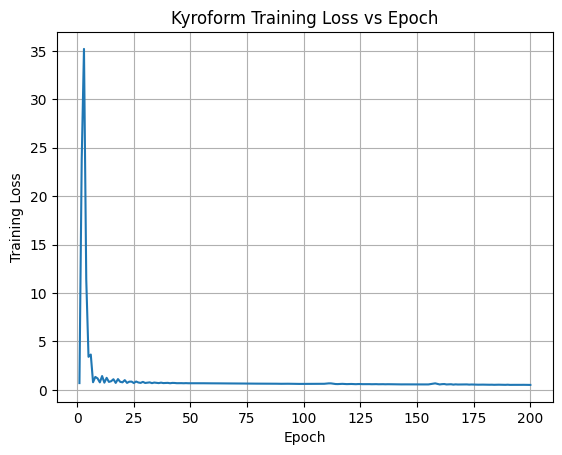

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(1, len(train_losses) + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Kyroform Training Loss vs Epoch")
plt.grid(True)
plt.show()

plt.savefig("kyroform_training_loss.png", dpi=300, bbox_inches="tight")

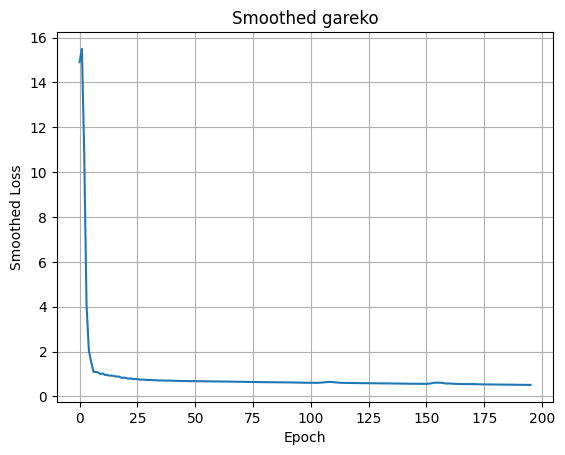

In [ ]:
import numpy as np

window = 5
smoothed = np.convolve(train_losses, np.ones(window)/window, mode='valid')

plt.figure()
plt.plot(smoothed)
plt.xlabel("Epoch")
plt.ylabel("Smoothed Loss")
plt.title("Smoothed gareko")
plt.grid(True)
plt.show()


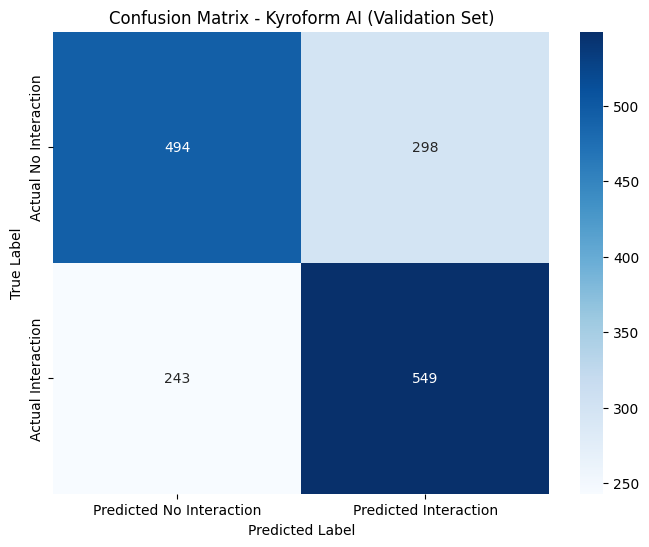

                precision    recall  f1-score   support

No Interaction       0.67      0.62      0.65       792
   Interaction       0.65      0.69      0.67       792

      accuracy                           0.66      1584
     macro avg       0.66      0.66      0.66      1584
  weighted avg       0.66      0.66      0.66      1584



"\nprint(classification_report(val_label.cpu(), val_pred_binary.cpu(), \n                            target_names=['No Interaction', 'Interaction']))\nyo seg ni use garna mann cha vane use or not\n"

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    z = model(data.x_dict, data.edge_index_dict)
    val_pos_pred = decode(z['human'][pos_edge[0][val_mask]], z['bacterial'][pos_edge[1][val_mask]])
    val_neg_pred = decode(z['human'][torch.randint(0, z['human'].size(0), val_mask.shape)],
                          z['bacterial'][torch.randint(0, z['bacterial'].size(0), val_mask.shape)])
    val_pred = torch.cat([val_pos_pred, val_neg_pred])
    val_probs = torch.sigmoid(val_pred)
    val_pred_binary = (val_probs > 0.5).int()  # Threshold 0.5
    val_label = torch.cat([torch.ones(val_pos_pred.size(0)), torch.zeros(val_neg_pred.size(0))]).int()

# Confusion Matrix
cm = confusion_matrix(val_label.cpu(), val_pred_binary.cpu())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Interaction', 'Predicted Interaction'],
            yticklabels=['Actual No Interaction', 'Actual Interaction'])
plt.title('Confusion Matrix - Kyroform AI (Validation Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


print(classification_report(val_label.cpu(), val_pred_binary.cpu(),
                            target_names=['No Interaction', 'Interaction']))
"""
print(classification_report(val_label.cpu(), val_pred_binary.cpu(),
                            target_names=['No Interaction', 'Interaction']))
yo seg ni use garna mann cha vane use or not
"""